## This notebook is for visualizing the diversity of the training set (such as distributional plots)

In [1]:
import os
import pandas as pd
import numpy as np
import skimage
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [2]:
path = '/scr/yren/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))
df = df[df.split == 'train'] # only draw training set
df.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.50,train,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.50,train,RPE1
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa


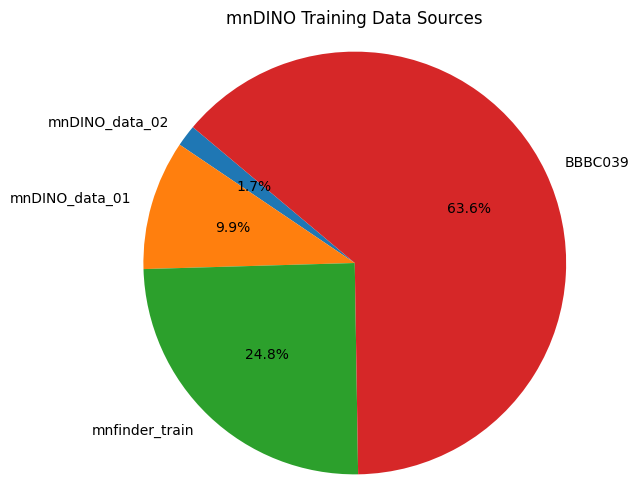

In [3]:
counter = Counter(df.datasets.to_list())

# Extract labels and sizes
labels = list(counter.keys())
sizes = list(counter.values())

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('mnDINO Training Data Sources')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Number of micronuclei violin plot

In [4]:
subsets = ['mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train', 'BBBC039']
df['number_of_mn'] = None
for subset in subsets:
    df_sub = df[df.datasets == subset]
    
    for i in range(df_sub.shape[0]):
        filename = df_sub.iloc[i]['filenames']
        im = skimage.io.imread(os.path.join(path, 'train', 'mn_masks', filename.replace('.tif', '.png')))
        number_of_mn = np.max(np.unique(skimage.measure.label(im)))
        
        df.loc[(df.filenames == filename) & (df.datasets == subset), 'number_of_mn'] = number_of_mn
        

Text(0.5, 1.0, 'Number of Micronuclei in Each Dataset')

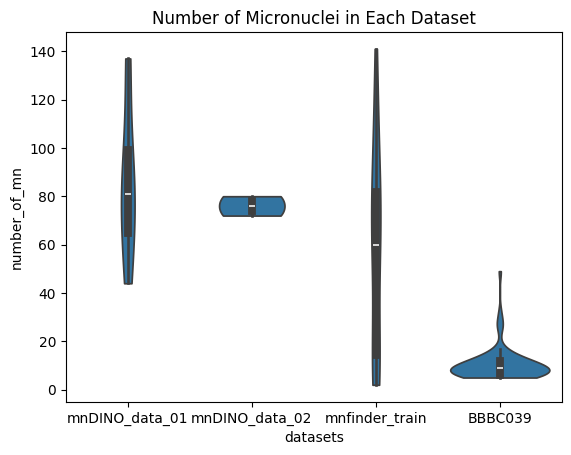

In [5]:
fig, ax = plt.subplots()

custom_order = ['mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train', 'BBBC039']
sns.violinplot(x='datasets', y='number_of_mn', data=df, ax=ax, cut=0, order=custom_order)
plt.title('Number of Micronuclei in Each Dataset')
# ax.set_ylim(0, 200)

# Area of micronuclei violin plot

In [6]:
mndino_01 = {}
mndino_02 = {}
mnfinder_train = {}
bbbc039 = {}

subsets = ['mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train', 'BBBC039']
for subset in subsets:
    df_sub = df[df.datasets == subset]
    
    for i in range(df_sub.shape[0]):
        filename = df_sub.iloc[i]['filenames']
        im = skimage.io.imread(os.path.join(path, 'train', 'mn_masks', filename.replace('.tif', '.png')))
        
        labels = skimage.measure.label(im)
        
        for label in range(1, np.max(labels) + 1):
            area = np.sum(labels == label)
            
            if subset == 'mnDINO_data_01':
                mndino_01[label] = area
            elif subset == 'mnDINO_data_02':
                mndino_02[label] = area
            elif subset == 'mnfinder_train':
                mnfinder_train[label] = area
            elif subset == 'BBBC039':
                bbbc039[label] = area

In [7]:
d = [mndino_01, mndino_02, mnfinder_train, bbbc039]
subsets = ['mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train', 'BBBC039']

df_area = pd.DataFrame(columns=['mn_label', 'area_of_mn', 'datasets'])
for i in range(4):
    df_sub = pd.DataFrame(d[i].items(), columns=['mn_label', 'area_of_mn'])
    df_sub['datasets'] = subsets[i]
    df_area = pd.concat([df_area, df_sub], ignore_index=True)

Text(0.5, 1.0, 'Area of Micronuclei in Each Dataset')

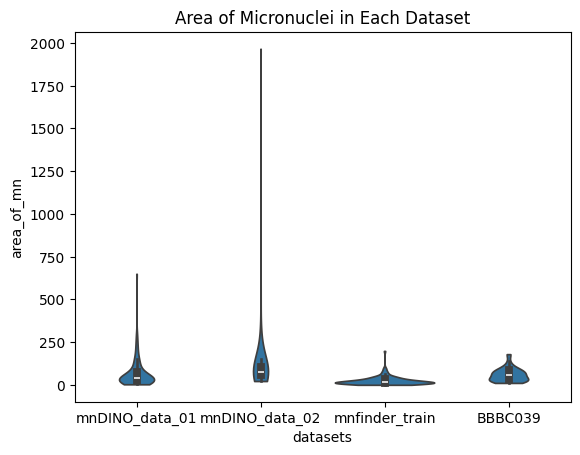

In [8]:
fig, ax = plt.subplots()

custom_order = ['mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train', 'BBBC039']
sns.violinplot(x='datasets', y='area_of_mn', data=df_area, ax=ax, cut=0, order=custom_order)
plt.title('Area of Micronuclei in Each Dataset')
# ax.set_ylim(0, 200)